In [18]:
url = 'https://en.wikipedia.org/wiki/Machine_learning'

In [19]:
# getting the data

import requests

headers = {
    'User-Agent': 'Colab Notebook/1.0 (https://colab.research.google.com; example@example.com)'
}
text = requests.get(url, headers=headers).content.decode('utf-8')
print(text[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Machine learning - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vec

In [20]:
# transforming the data
## we need to convert html data into plain texts
## we will use BeautifulSoup a python library for parsing html

import sys
!{sys.executable} -m pip install beautifulsoup4


In [21]:
from bs4 import BeautifulSoup

# parse the html content
soup = BeautifulSoup(text, 'html.parser')

# extract only the main article content from wikipedia
# wikipedia uses 'mx-parser-output' class for the main article content
content = soup.find('div', class_='mw-parser-output')

def clean_wikipedia_content(content_node):
  # strip jump links, navboxes, etc
  selectors = [
      '.mw-jump-link',
      '.navbox',
      '.reflist',
      'sup.reference',
      '.mw-editsection',
      '.hatnote',
      '.metadata',
      '.infobox',
      '#toc',
      '.toc',
      '.sidebar',
  ]
  for selector in selectors:
    for el in content_node.select(selector):
      el.decompose() # .decompose() removes a tag from the tree, then completely destroys it and its contents:

if content:
  clean_wikipedia_content(content)
  text = content.get_text(separator=' ', strip=True)
  print(text[:1000])
else:
  print("Could not find main content.")
  text = soup.get_text(separator=' ', strip=True)
  print(text[:1000])

Subset of artificial intelligence Machine learning ( ML ) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed . Advances in the field of deep learning have allowed neural networks , a class of statistical algorithms, to surpass many previous machine learning approaches in performance. Statistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning . From a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning algorithms can be described as empirical risk minimisation under this framework. History The term machine learning was co

In [22]:
# getting insights
# use python library RAKE for keyword extraction

import sys
!{sys.executable} -m pip install nlp_rake

In [33]:
import nlp_rake

extractor = nlp_rake.Rake(max_words=2, min_freq=8, min_chars=5)
res = extractor.apply(text)
res

[('data mining', 4.0),
 ('mit press', 4.0),
 ('wayback machine', 3.979166666666667),
 ('reinforcement learning', 3.958333333333333),
 ('machine learning', 3.9375),
 ('artificial intelligence', 3.8736842105263154),
 ('supervised learning', 3.867424242424242),
 ('pattern recognition', 3.857142857142857),
 ('unsupervised learning', 3.7765151515151514),
 ('algorithms', 1.6333333333333333),
 ('systems', 1.6296296296296295),
 ('training', 1.6285714285714286),
 ('models', 1.5909090909090908),
 ('model', 1.564102564102564),
 ('examples', 1.5555555555555556),
 ('input', 1.5),
 ('applications', 1.3333333333333333),
 ('output', 1.3076923076923077),
 ('learn', 1.2727272727272727),
 ('inputs', 1.2727272727272727),
 ('performance', 1.1818181818181819),
 ('field', 1.1578947368421053),
 ('trained', 1.1538461538461537),
 ('features', 1.1111111111111112),
 ('study', 1.1),
 ('original', 1.0375),
 ('statistics', 1.0),
 ('archived', 1.0),
 ('peter', 1.0),
 ('bibcode', 1.0),
 ('christopher', 1.0),
 ('procee

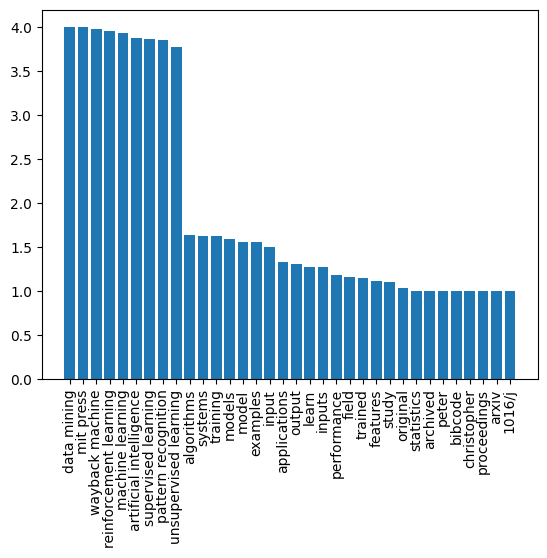

In [34]:
# visualising result

import matplotlib.pyplot as plt

def plot(pair_list):
  k, v = zip(*pair_list)
  plt.bar(range(len(k)),v)
  plt.xticks(range(len(k)), k, rotation='vertical')
  plt.show()

plot(res)

In [35]:
# word cloud
!{sys.executable} -m pip install wordcloud

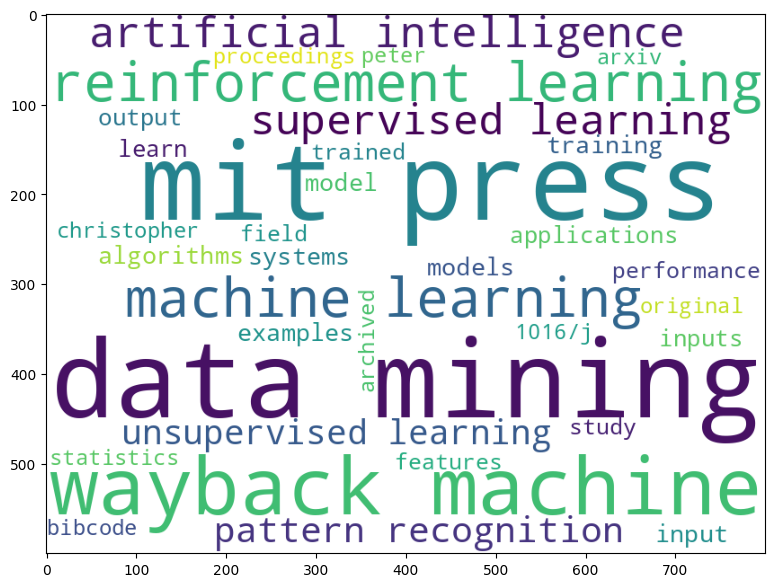

In [36]:
from wordcloud import WordCloud

wc = WordCloud(background_color='white', width=800, height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({k:v for k,v in res}))

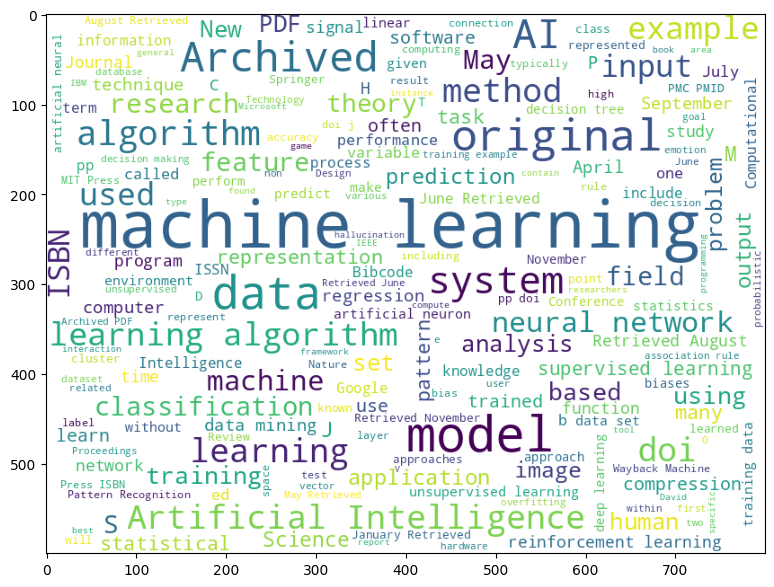

In [37]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(text))